<a href="https://colab.research.google.com/github/lightsara/2025v11-blog/blob/master/CB206V_knn_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#K-NN CLASSIFIER


###Install and load packages. Import data.

In [1]:
# Installing necessary packages
# !pip install numpy scikit-learn

# Importing libraries
import numpy as np
from sklearn.model_selection import train_test_split  # we use this for sample.split
from sklearn.preprocessing import StandardScaler      # we use this for scaling
from sklearn.neighbors import KNeighborsClassifier    # This does the knn classification


Next, we need to read in our data. I have deposited the data in my GitHub pages and you can directly download it from there using the URL:

In [2]:
import pandas as pd

# URL of the file hosted on GitHub
url = "https://gist.githubusercontent.com/Vihervaara/6aa2bde9b2f016bb7cfc68380dcb37aa/raw/58d527b563d0d32c19c7f64af0b15c278b2398c7/HSF1_bindingSites_HDgroups.txt"

# Read the file directly into a pandas DataFrame
df = pd.read_csv(url, sep="\t")  # tab-delimited data frame

# Display the first 6 rows
print(df.head())


     chr     start       end   HDgroup   DNaseI        GATA1   Nucleosome  \
0   chr7  75923331  75924845  enhancer  37.6700  2019.199997  1287.200003   
1   chr7  27773783  27774970  enhancer  11.5713  1964.099996  1311.799999   
2  chr19   2398311   2399287  enhancer   6.5281  1518.499980   933.100000   
3  chr16  89050113  89051597  enhancer  19.5406  3181.100002  1501.600004   
4  chr19   5863588   5865998  enhancer  45.3413  5939.400014  3127.700002   

   H3K4me1  H3K4me3         Pol2       TAF1  
0   121981     7494  6333.499958  82.190107  
1     6882     1485  2031.399994   0.000000  
2    11055     2047   571.100001   0.000000  
3    81954     2859  3779.700008  12.484584  
4    32354     6782  2507.099991  12.715778  


###Q1. Look at the imported data.
####1A: What do the first 3 columns indicate?
####1B: What type of information is given in the following columns?
####1C: Should the data be scaled?

###Familiarising with the data. Basic plotting.

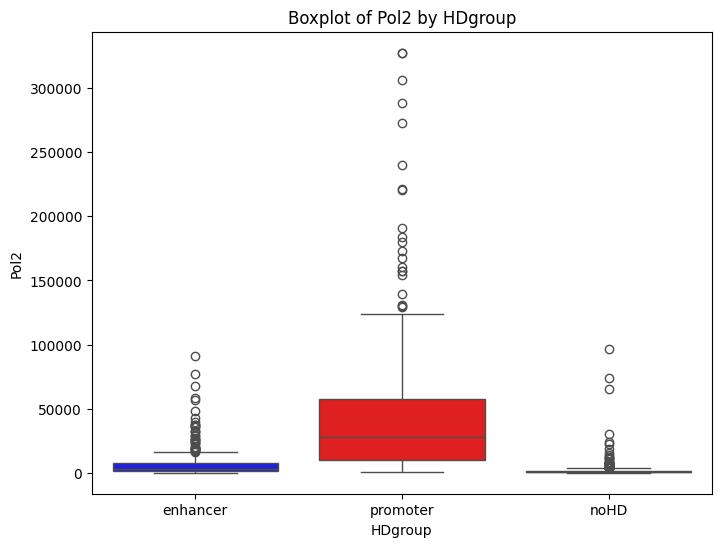

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


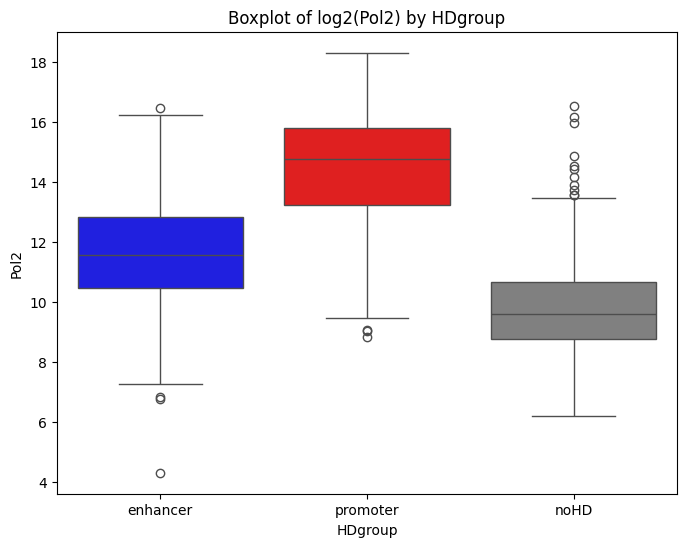

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# First boxplot (without log transformation)
plt.figure(figsize=(8, 6))
sns.boxplot(x='HDgroup', y='Pol2', data=df, hue='HDgroup', palette=["blue", "red", "grey"], legend=False)
plt.title('Boxplot of Pol2 by HDgroup')
plt.show()

# Second boxplot (with log2 transformation)
plt.figure(figsize=(8, 6))
sns.boxplot(x='HDgroup', y=np.log2(df['Pol2']), data=df, hue='HDgroup', palette=["blue", "red", "grey"], legend=False)
plt.title('Boxplot of log2(Pol2) by HDgroup')
plt.show()


Above, we graphed how much RNA Polymerase II (Pol2) occupies genomic regions that have been classified either as a promoter, enhancer, or untranscribed regulatory region (noHD).

A good idea is to also to look at the structure and dimensions of the data you are working with:

In [5]:
# Check the structure of the data
print(df.info())  # Provides information about columns, non-null values, and data types

# Check the dimensions of the data
print(df.shape)  # Provides the number of rows and columns in a tuple (rows, columns)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1295 entries, 0 to 1294
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   chr         1295 non-null   object 
 1   start       1295 non-null   int64  
 2   end         1295 non-null   int64  
 3   HDgroup     1295 non-null   object 
 4   DNaseI      1295 non-null   float64
 5   GATA1       1295 non-null   float64
 6   Nucleosome  1295 non-null   float64
 7   H3K4me1     1295 non-null   int64  
 8   H3K4me3     1295 non-null   int64  
 9   Pol2        1295 non-null   float64
 10  TAF1        1295 non-null   float64
dtypes: float64(5), int64(4), object(2)
memory usage: 111.4+ KB
None
(1295, 11)


###Split the data into testing data and training data

Let's first split the data into training data and test data. A general guideline is to take around 70-80% to the training data and leave the rest to the test data. We have a relative small set of data and go therefore with 70-30. You can change this and test different ratios if you want.

In [6]:
from sklearn.model_selection import train_test_split

# Split the data (70% training, 30% testing)
train_dat, test_dat = train_test_split(df, test_size=0.3, random_state=42) #train_dat contains the training data (70%). test_dat contains the test data (30%).

# Check the dimensions of the training data
print(train_dat.shape)


(906, 11)


Next, we select H3K4me1, H3Keme3 and Pol2 ChIP-seq data and scale the their values.

Q: Why do you think it is important to scale the data?

In [8]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()
print(train_dat)
# Scale the selected columns in train and test data
train_scale = scaler.fit_transform(train_dat[['H3K4me1', 'H3K4me3', 'Pol2']]) #🟦🟦🟦🟦🟦
test_scale = scaler.transform(test_dat[['H3K4me1', 'H3K4me3', 'Pol2']])       #🟦🟦🟦🟦🟦

# View the scaled test data
print(test_scale[:5])

# EXTRA for LATER. #🟦🟦🟦🟦🟦
# To scale all 7 ChIP-seq datasets, uncomment and run the lines below
# train_scale = scaler.fit_transform(train_dat.iloc[:, 4:11])  # Columns 5 to 11 (zero-indexed) #🟦🟦🟦🟦🟦
# test_scale = scaler.transform(test_dat.iloc[:, 4:11])        # Columns 5 to 11 (zero-indexed) #🟦🟦🟦🟦🟦


StandardScaler()
[[-0.39705997 -0.40778911 -0.43752009]
 [ 0.00669331 -0.38975745 -0.00879796]
 [ 0.02011607 -0.38813326 -0.4061772 ]
 [ 0.13602118 -0.38199918 -0.33619013]
 [ 0.32908657 -0.39593883 -0.3825724 ]]


Q2: What happenned to the data during scaling?

### Training the classifier.

Here, we train the classifier. Let's start with k=1

You will change the k later.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# Initialize the k-NN classifier with k=1
classifier_knn = KNeighborsClassifier(n_neighbors=1)  #🟨🟨🟨🟨🟨 RUN FIRST WITH K=1.
                                                      #🟨🟨🟨🟨🟨 RETURN TO THIS STAGE TO CHANGE THE K

# Fit the model with the scaled training data and the class labels
classifier_knn.fit(train_scale, train_dat['HDgroup'])

# Predict the classes for the test data
predictions = classifier_knn.predict(test_scale)

print(predictions[:5])

print(test_dat['HDgroup'].head(10))

['noHD' 'enhancer' 'noHD' 'enhancer' 'promoter']
834         noHD
327     enhancer
839         noHD
1121        noHD
976         noHD
536     promoter
477     promoter
1078        noHD
889         noHD
76      enhancer
Name: HDgroup, dtype: object


Ok. the model has been trained. Let's lok how the classifier performed:

[[60 40 27]
 [39 92 10]
 [36  5 80]]


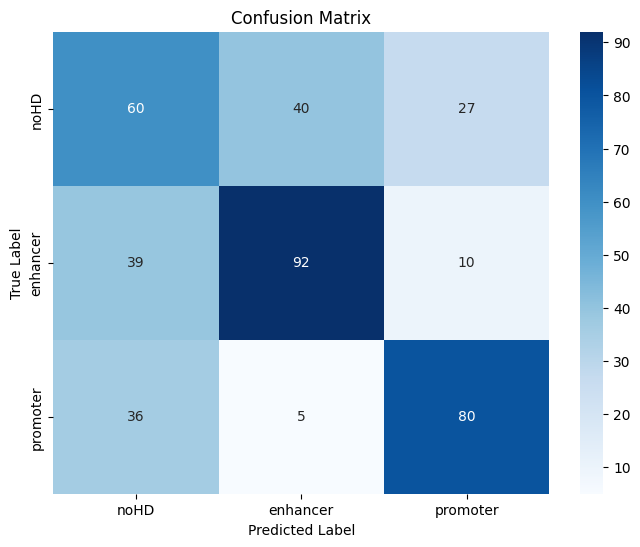

In [ ]:


# Compute the confusion matrix
cm = confusion_matrix(test_dat['HDgroup'], predictions)

print(cm)

actual_labels = test_dat['HDgroup'].unique()

# Visualize the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=actual_labels,  # Use actual labels for x-axis
            yticklabels=actual_labels)  # Use actual labels for y-axis
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix above tells how many enhancers, UREs and promoters (rows) were classified (columns). In essence, confusion matrix tells you how many enhancers were correctly classified as enhancer, and how many were mislabelled as UREs (noHD) or promoters.

We can get a number on the performance:

In [ ]:
# Calculate the misclassification error
misClassError = np.mean(predictions != test_dat['HDgroup'])

# Calculate and print the accuracy
accuracy = 1 - misClassError
print(f'Accuracy = {accuracy:.4f}')  # Display accuracy to 4 decimal places

Accuracy = 0.6658


#Is this accuracy acceptale?

_______________________________
Go back to the knn() step above 🟨🟨🟨🟨🟨🟨🟨.

WHAT CAN YOU DO TO IMPROVE THE CLASSIFIER?


Re-run the code a couple times with a different training parameter.
What do you detect?



_______________________________

ASK IF YOU DON'T UNDERSTAND.
It is important that you can run these steps and work with the classifier.

# Find the optimal K


###...it gets cumbersome to manually change the parameter in search of the optimal k....

###Can we automate the code to find the best k ?

In [ ]:
# Define the function to return only odd numbers
def justodd(x):
    return [i for i in x if i % 2 == 1]

# Test the function with a range of numbers
print(justodd(range(1, 21)))


[1, 3, 5, 7, 9, 11, 13, 15, 17, 19]


Define the highest k you want to test. I choose 300 below, defined by 'range':

The range depends on your data, e.g. on how many data points you have. (We have ca 900 data points in the test_data. Giving too high of a k leads to a "largest-group-takes-it-all" effect. You can test what happens if giving k=900 in the code above.)

with K=1 Accuracy = 0.5964
with K=3 Accuracy = 0.6452
with K=5 Accuracy = 0.6658
with K=7 Accuracy = 0.6607
with K=9 Accuracy = 0.6478
with K=11 Accuracy = 0.6581
with K=13 Accuracy = 0.6710
with K=15 Accuracy = 0.6735
with K=17 Accuracy = 0.6710
with K=19 Accuracy = 0.6632
with K=21 Accuracy = 0.6632
with K=23 Accuracy = 0.6658
with K=25 Accuracy = 0.6632
with K=27 Accuracy = 0.6684
with K=29 Accuracy = 0.6710
with K=31 Accuracy = 0.6555
with K=33 Accuracy = 0.6761
with K=35 Accuracy = 0.6735
with K=37 Accuracy = 0.6787
with K=39 Accuracy = 0.6787
with K=41 Accuracy = 0.6735
with K=43 Accuracy = 0.6632
with K=45 Accuracy = 0.6710
with K=47 Accuracy = 0.6761
with K=49 Accuracy = 0.6735
with K=51 Accuracy = 0.6812
with K=53 Accuracy = 0.6735
with K=55 Accuracy = 0.6735
with K=57 Accuracy = 0.6710
with K=59 Accuracy = 0.6684
with K=61 Accuracy = 0.6632
with K=63 Accuracy = 0.6684
with K=65 Accuracy = 0.6632
with K=67 Accuracy = 0.6710
with K=69 Accuracy = 0.6658
with K=71 Accuracy = 0.66

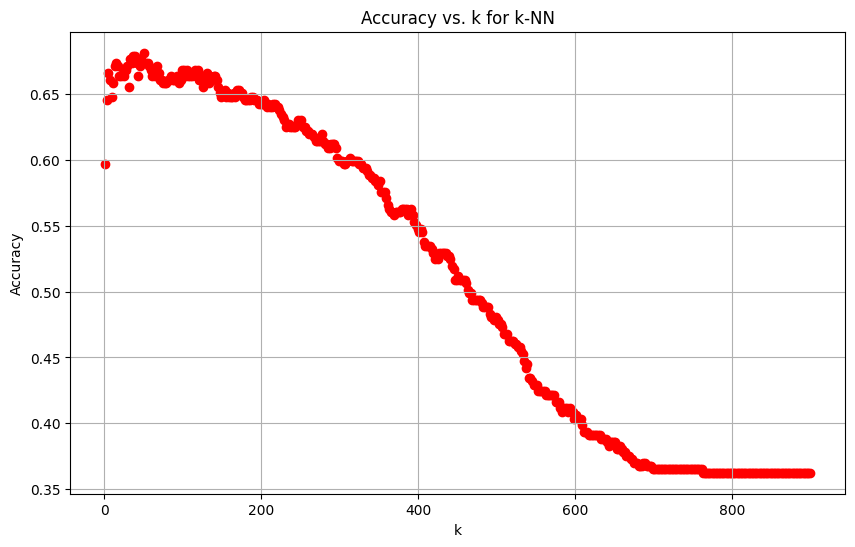

In [ ]:
range_val = 900

# Initialize lists to store k values and accuracies
k_list = []
accuracy_list = []

true_labels = test_dat['HDgroup']

for k in justodd(range(1, range_val)):
    classifier_knn = KNeighborsClassifier(n_neighbors=k)
    classifier_knn.fit(train_scale, train_dat['HDgroup'])
    predictions = classifier_knn.predict(test_scale)

    misClassError = np.mean(predictions != true_labels)
    accuracy = 1 - misClassError

    print(f'with K={k} Accuracy = {accuracy:.4f}')

    k_list.append(k)
    accuracy_list.append(accuracy)

    k_frame = pd.DataFrame({
    'k': k_list,
    'accuracy': accuracy_list
})

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(k_frame['k'], k_frame['accuracy'], c='red', marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. k for k-NN')
plt.grid(True)
plt.show()

## Which k yielded the most optimal performance?

You might be able to read it from the graph, but let's derive it from the data frame:

In [ ]:
max_accuracy_row = k_frame[k_frame['accuracy'] == k_frame['accuracy'].max()]

print(max_accuracy_row)

     k  accuracy
25  51  0.681234


The exact k you get might differ between the training rounds.
This is due to randomly splitting the data in the early part of the code. Each time you randomly split, you get different training and test data. With small datasets, this can have an effect.

You might also have two (or several) k:s with the same max performance.

#EXTRA for the fastest ones (or to do at home): #🟦🟦🟦🟦🟦

### Now that you made it all the way here, go back up to the step where you re-load the df from the GitHub.

#### After re-loading the df, re-run the code with all seven chromatin markers.

#### you can skip the manually testing. Just split, scale, and run the loop with 1:range of k.


## Does your classifier improve with more data?